# Employee Promotion Prediction using Random Forest

In [1]:
import urllib.request
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Download Data
DATA_FILE = 'employee_promotion.csv'
DATA_URL = 'https://raw.githubusercontent.com/rajtulluri/Employee-Promotion-Prediction/master/employeePromotion.csv'

if not os.path.exists(DATA_FILE):
    print(f'Downloading data from {DATA_URL}...')
    urllib.request.urlretrieve(DATA_URL, DATA_FILE)
else:
    print(f'{DATA_FILE} already exists. Skipping download.')

df = pd.read_csv(DATA_FILE)
df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,0,73,0


Target distribution:
is_promoted
0    50140
1     4668
Name: count, dtype: int64
Training Random Forest Classifier...
Accuracy: 0.9343
F1 Score: 0.4249

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.97     10028
           1       0.84      0.28      0.42       934

    accuracy                           0.93     10962
   macro avg       0.89      0.64      0.70     10962
weighted avg       0.93      0.93      0.92     10962



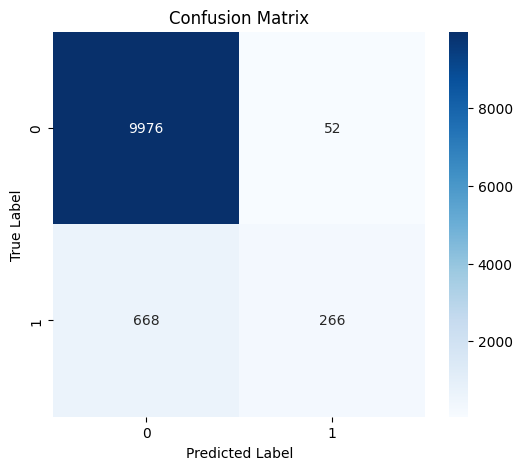

In [2]:
# Preprocess and Train
if 'employee_id' in df.columns:
    df = df.drop('employee_id', axis=1)

if 'education' in df.columns:
    df['education'] = df['education'].fillna(df['education'].mode()[0])
if 'previous_year_rating' in df.columns:
    df['previous_year_rating'] = df['previous_year_rating'].fillna(df['previous_year_rating'].mean())

categorical_cols = df.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

target = 'is_promoted'
X = df.drop(target, axis=1)
y = df[target]

print(f'Target distribution:\n{y.value_counts()}')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('Training Random Forest Classifier...')
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

predictions = model.predict(X_test)
acc = accuracy_score(y_test, predictions)
f1 = f1_score(y_test, predictions)

print(f'Accuracy: {acc:.4f}')
print(f'F1 Score: {f1:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, predictions))

# Confusion Matrix
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()